In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner

sys.path.append('/local/hpaugnat/lensqso-specfit')

from spectrum_model import QuasarSpectrum
from multi_spectrum import MultiSpectrum
from multi_spec_fitter import Optimizer, PSO, MCMCSampler, FittingSequence

In [2]:
kwargs_model = {'continuum': 'powerlaw', #('polynomial',1), 
                'narrow_doublets': [('OIII',5)], 
                'single_lines': [('Hbeta',5, 'broad'), 
                                 #('Hbeta',0, 'narrow')
                                ],
                'Template_lines': ['FeII']} 

In [3]:
kwargs_data = {}
for image_name in ['A', 'B', 'C', 'D']:
    data = np.load('example_spectrum_'+image_name+'.npy')
    data[2][data[2]<5e-3] = 5e-3 #some points have understimated error
    kwargs_data[image_name] = data


kwargs_fixed = {'ref_image': 'A', 
                'fixed_params':{'OIII_narrow_doublet':['dlam', 'width', 'relcoeffsHermite'],
                                'Hbeta_broad':[],
                                #'Hbeta_narrow':['dlam', 'width'],
                               'FeII_template': ['dlam', 'velocity', 'relG', 'relIZw1', 'relS']
                               }}

qso_spec = MultiSpectrum(kwargs_data=kwargs_data, kwargs_model=kwargs_model, kwargs_fixed=kwargs_fixed)
print(qso_spec.param_handler.free_nonlinear_param_list)
#print(qso_spec.param_handler.kwargs_nonlinear_mult)

qso_spec.set_priors('continuum', {'beta':[0,0.1,-1,1]}, images='all')
qso_spec.set_priors('OIII_narrow_doublet', {'width':[5,0.1,0,10], 'dlam':[5,1,-10,15]}, images=['A'])
qso_spec.set_priors('Hbeta_broad', {'width':[40, 7.5, 10, 80]}, images='all')
qso_spec.set_priors('Hbeta_broad', {'dlam':[1, 1, -40, 40]}, images=['A'])
qso_spec.set_initial_values()

#array = qso_spec.param_handler.kwargs_nonlinear2array()
#print(array)
#print(qso_spec.param_handler.array2kwargs_nonlinear(array))

#print(qso_spec.param_handler.kwargs_nonlinear_mult)
#print(qso_spec.get_bounds_free_nonlinear_params())

#logL, kwargs_values = qso_spec.log_likelihood_from_kwargs()
#simulated_flux = qso_spec.simulateSpectra(kwargs_values, plot=True)
#print(logL)

['continuum_beta_A', 'OIII_narrow_doublet_dlam_A', 'OIII_narrow_doublet_width_A', 'OIII_narrow_doublet_relcoeffsHermite1_A', 'OIII_narrow_doublet_relcoeffsHermite2_A', 'OIII_narrow_doublet_relcoeffsHermite3_A', 'OIII_narrow_doublet_relcoeffsHermite4_A', 'OIII_narrow_doublet_relcoeffsHermite5_A', 'Hbeta_broad_dlam_A', 'Hbeta_broad_width_A', 'FeII_template_dlam_A', 'FeII_template_velocity_A', 'FeII_template_relG_A', 'FeII_template_relIZw1_A', 'FeII_template_relS_A', 'continuum_beta_B', 'Hbeta_broad_dlam_B', 'Hbeta_broad_width_B', 'continuum_beta_C', 'Hbeta_broad_dlam_C', 'Hbeta_broad_width_C', 'continuum_beta_D', 'Hbeta_broad_dlam_D', 'Hbeta_broad_width_D']


In [4]:
#Define custom masks to remove some artifacts

mask_B = 1- (kwargs_data[image_name][0] > 4710) * (kwargs_data[image_name][0] < 4730)
mask_B *= 1- (kwargs_data[image_name][0] > 5150) * (kwargs_data[image_name][0] < 5185) 

mask_D = 1- (kwargs_data[image_name][0] > 4837) * (kwargs_data[image_name][0] < 4847)

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [06:26<00:00,  2.59it/s]


Max iteration reached! Stopping.
Time taken for PSO optimization:  386.42101669311523
Computing the MCMC...
Number of walkers:  100
Burn-in iterations:  100
Sampling iterations (in current run): 1100


  0%|                                                                                          | 0/1100 [00:00<?, ?it/s]/home/hpaugnat/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████████| 1100/1100 [06:55<00:00,  2.65it/s]

Time taken for MCMC sampling:  415.82472586631775



/local/hpaugnat/lensqso-specfit/multi_spec_fitter.py:157: RuntimeWarning: invalid value encountered in divide
  samples_renormed = (samples_averaged - end_point) / np.std(samples_averaged)
/local/hpaugnat/lensqso-specfit/multi_spec_fitter.py:160: RuntimeWarning: invalid value encountered in subtract
  dist_normed = (dist_averaged - np.nanmax(dist_averaged)) / (


{'A': {'continuum': {'beta': 0.8234356281430164, 'amp': 0.10043222654239183},
  'OIII_narrow_doublet': {'dlam': 2.2383850864090005,
   'width': 6.068372331793428,
   'relcoeffsHermite': array([ 0.36656905, -0.05830169,  0.01164766, -0.01662291,  0.00756213]),
   'amp': 0.3893107889385486},
  'Hbeta_broad': {'dlam': -1.292255977850263,
   'width': 40.48166496534553,
   'coeffsHermite': array([7.78264513, 4.3823885 , 1.21973356, 1.25654348, 0.15136694,
          0.11648783])},
  'FeII_template': {'dlam': 12.117178643019221,
   'velocity': 1522.180812684239,
   'relG': 0.3997095885563931,
   'relIZw1': 0.5839651832404494,
   'relS': 0.6902407462581175,
   'F': 0.24412690730638487}},
 'B': {'continuum': {'beta': 0.23012638297408144, 'amp': 0.14024640040565536},
  'OIII_narrow_doublet': {'dlam': 2.2383850864090005,
   'width': 6.068372331793428,
   'relcoeffsHermite': array([ 0.36656905, -0.05830169,  0.01164766, -0.01662291,  0.00756213]),
   'amp': 0.4000778791177687},
  'Hbeta_broad': {'

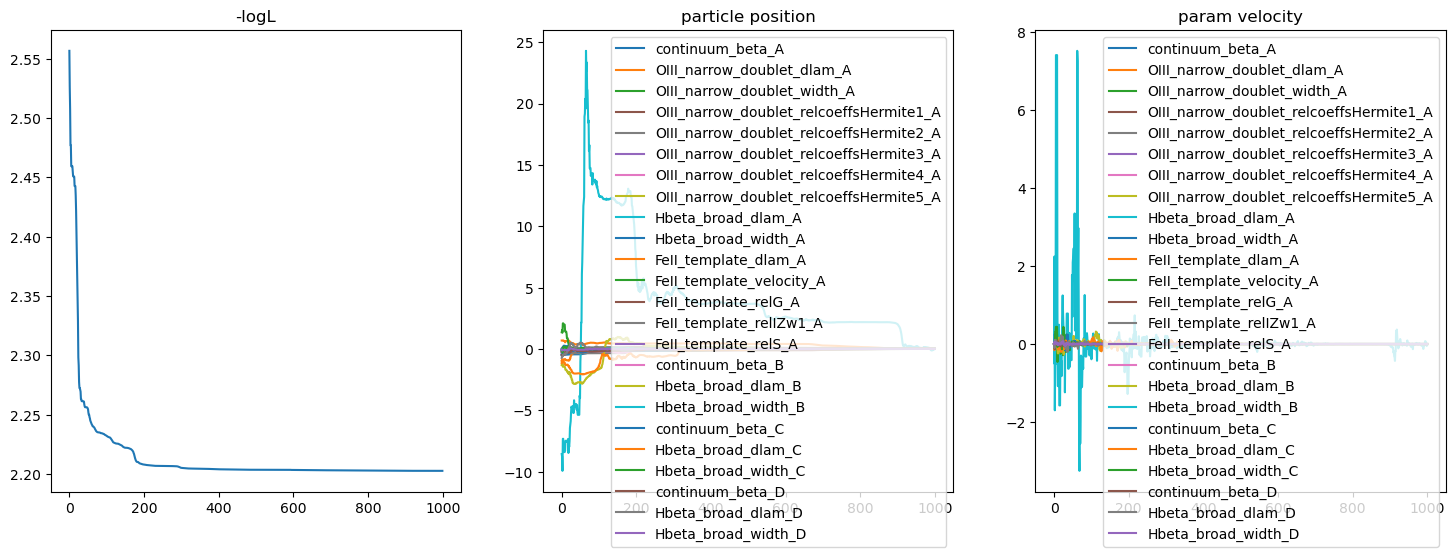

<Figure size 640x480 with 0 Axes>

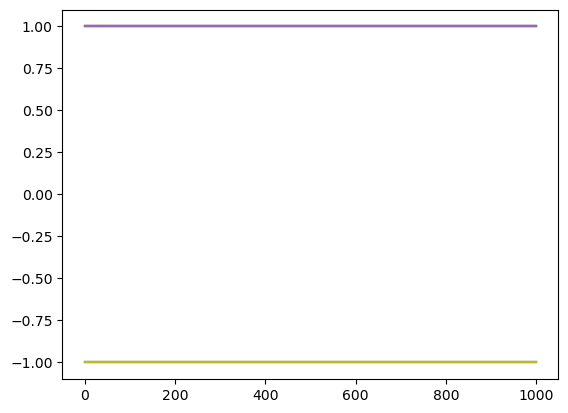

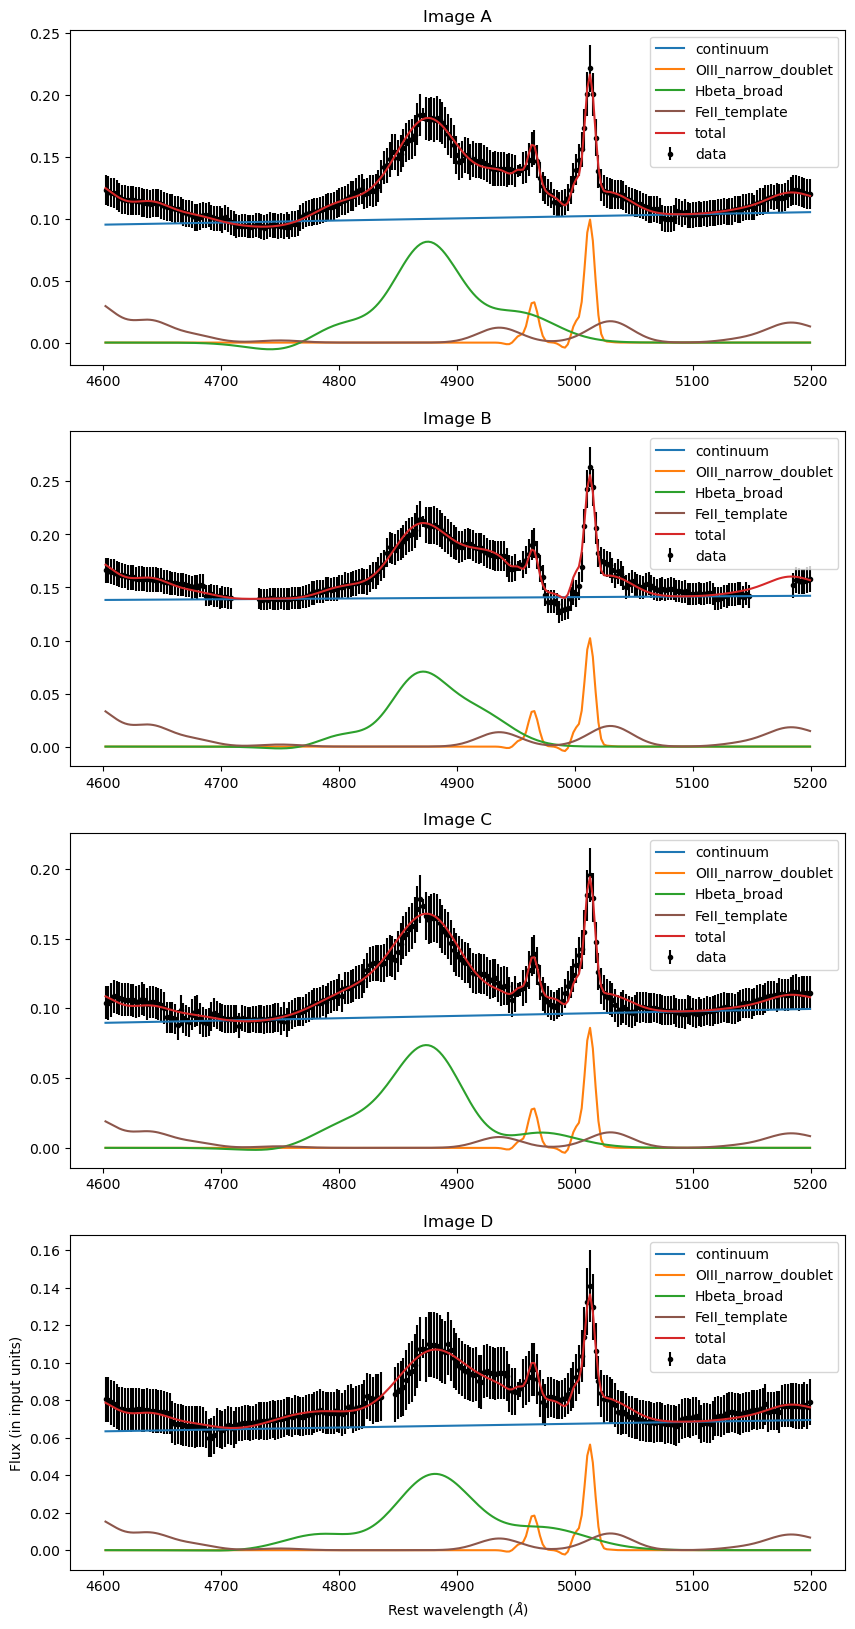

In [16]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -3e-2} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

fit_param_list = [('PSO', {'n_particles':100, 'max_iter':1000}),
                  ('update_kwargs_likelihood', {'tol_positive': -2e-3}),
                  ('MCMC', {'n_walkers':100, 'n_run':1000, 'n_burn':100, 'skip_initial_state_check':True})
                 ]

fitting_seq = FittingSequence(fit_param_list, qso_spec, kwargs_likelihood)
chain_seq = fitting_seq.run_sequence()
fitting_seq.plot_convergence()
fitting_seq.get_kwargs_values_best(plot=True)


['f_B/f_A', 'f_C/f_A', 'f_D/f_A']


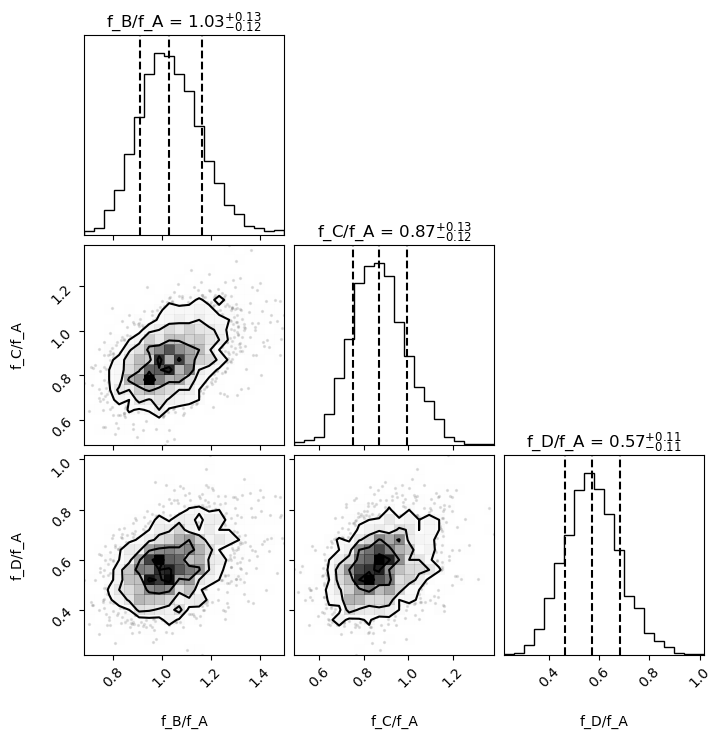

In [17]:
mcmc_sampler = MCMCSampler(qso_spec, kwargs_likelihood=kwargs_likelihood)
mcmc_sampler.samples_mcmc = chain_seq[1][3]
narrow_doublet_fluxratios_post, fr_names = mcmc_sampler.narrow_doublet_flux_ratio_posterior('OIII', n_samples=2000, n_burn_add=500)
print(fr_names)

figure = corner.corner(narrow_doublet_fluxratios_post, labels=list(fr_names),
    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

In [ ]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -3e-2} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = PSO(qso_spec, n_particles=100, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.optimize(max_iter=1000, plot=True)
#simulated_flux = qso_spec.simulateSpectra(kwargs_values, plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

In [15]:
for image in ['A', 'B', 'C', 'D']:
    print(kwargs_values[image]['OIII_narrow_doublet']['amp']/kwargs_values['A']['OIII_narrow_doublet']['amp'])

1.0
1.125875664325094
0.873631258299864
0.5687462485232455


### Save some other fits

 73%|██████████████████████████████████████████████████████████▏                     | 727/1000 [05:49<02:11,  2.08it/s]


Converged after 727 iterations!
Best fit found:  -169.9379301653604 [-0.31866486962065693, 3.9245173241547, 4.526576795897808, 0.2265411621257103, 0.092631933560196, -0.0031501309528501544, 0.0041411412738718515, 0.0025149575484975785, -1.2832995787984534, 35.170568288007864, -0.44238035692571026, 30.360344682071215, 14.634170906365345, 3696.200055137508, -0.24025197688260752, 1.4591232819863382, 30.745019544181734, -0.04201412306031131, 0.43041875289492826, 34.001832552884814, 0.370880312412395, 0.45972854164255456, 58.24153405093703]
Best-fitting parameters:  {'A': {'continuum': {'beta': -0.31866486962065693, 'amp': 0.08873651360440986}, 'OIII_narrow_doublet': {'dlam': 3.9245173241547, 'width': 4.526576795897808, 'relcoeffsHermite': array([ 0.22654116,  0.09263193, -0.00315013,  0.00414114,  0.00251496]), 'amp': 0.389545877380606}, 'Hbeta_broad': {'dlam': -1.2832995787984534, 'width': 35.170568288007864, 'coeffsHermite': array([9.17999157, 2.62132318, 2.08775492, 0.62776247, 0.211724

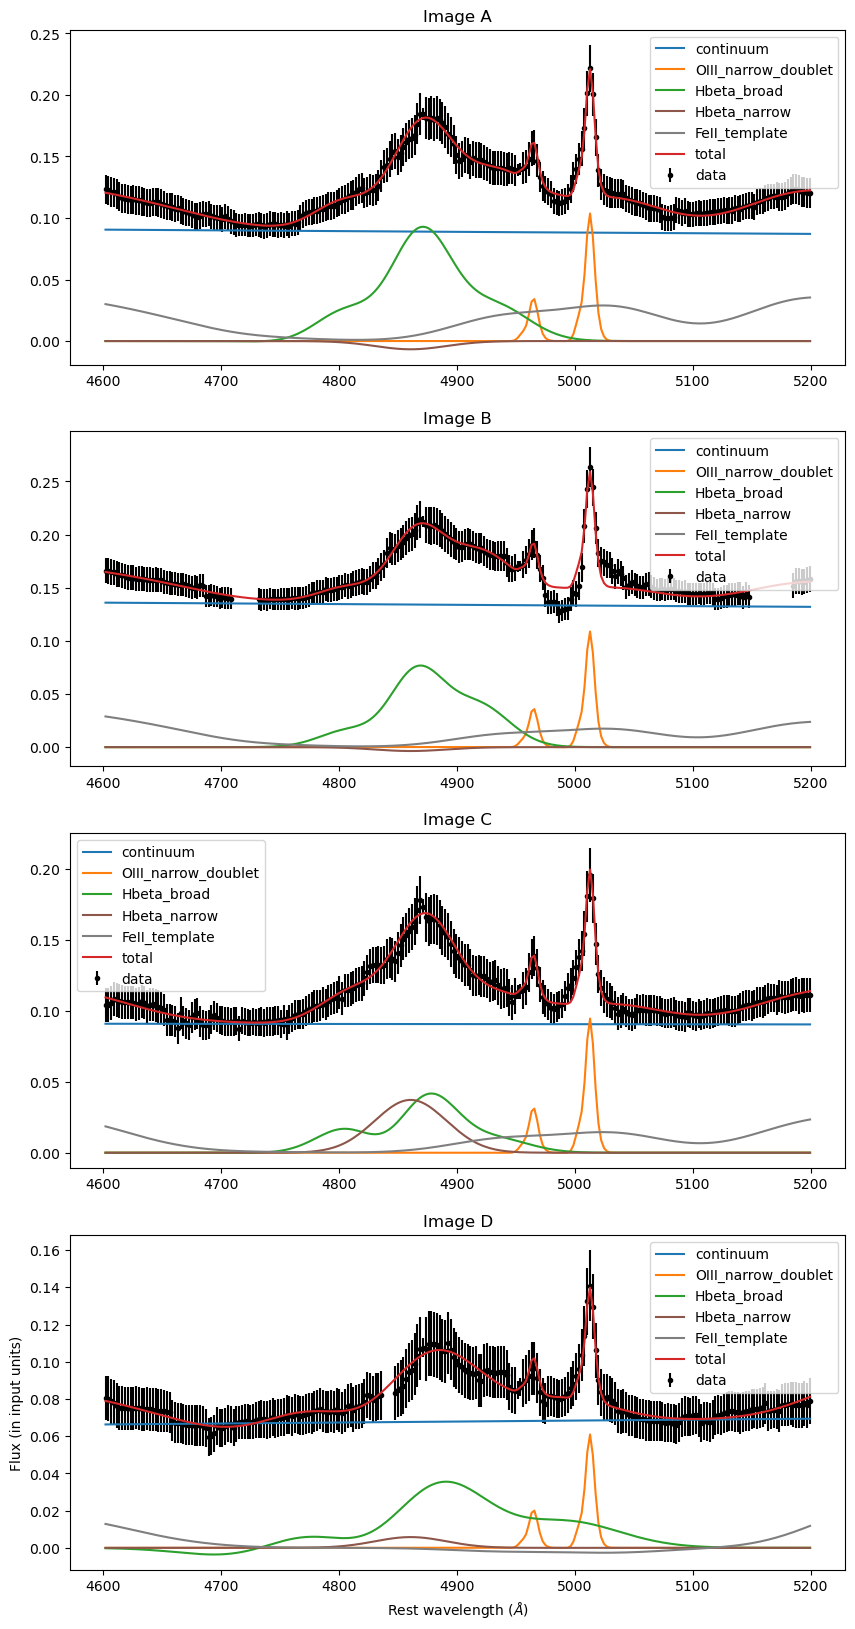

In [51]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -8e-3} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = PSO(qso_spec, n_particles=100, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.optimize(max_iter=1000, plot=True)
#simulated_flux = qso_spec.simulateSpectra(kwargs_values, plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

 83%|██████████████████████████████████████████████████████████████████▋             | 833/1000 [03:57<00:47,  3.51it/s]


Converged after 833 iterations!
Best fit found:  -174.40256658214219 [0.9999998150502843, 4.544207654033587, 5.42622396536427, 0.0850263491696655, 0.0873760555153471, 0.0031254752269609795, 0.016086120035874223, 0.004628515917278695, 0.4207255248956515, 38.9538184546209, 16.60138717491658, 1711.955344616298, 0.41307282122241906, 1.089108191020973, 30.344967122672518, 0.9999999991684401, 3.3770882709208734, 42.58084803074726, 0.9999986413282956, -10.003792653212566, 58.50655653915275]
Best-fitting parameters:  {'A': {'continuum': {'beta': 0.9999998150502843, 'amp': 0.09906468539544185}, 'OIII_narrow_doublet': {'dlam': 4.544207654033587, 'width': 5.42622396536427, 'relcoeffsHermite': array([0.08502635, 0.08737606, 0.00312548, 0.01608612, 0.00462852]), 'amp': 0.4456087035847899}, 'Hbeta_broad': {'dlam': 0.4207255248956515, 'width': 38.9538184546209, 'coeffsHermite': array([8.04604849, 3.65510034, 1.37543123, 0.984552  , 0.15932225,
       0.09328983])}, 'FeII_template': {'dlam': 16.601387

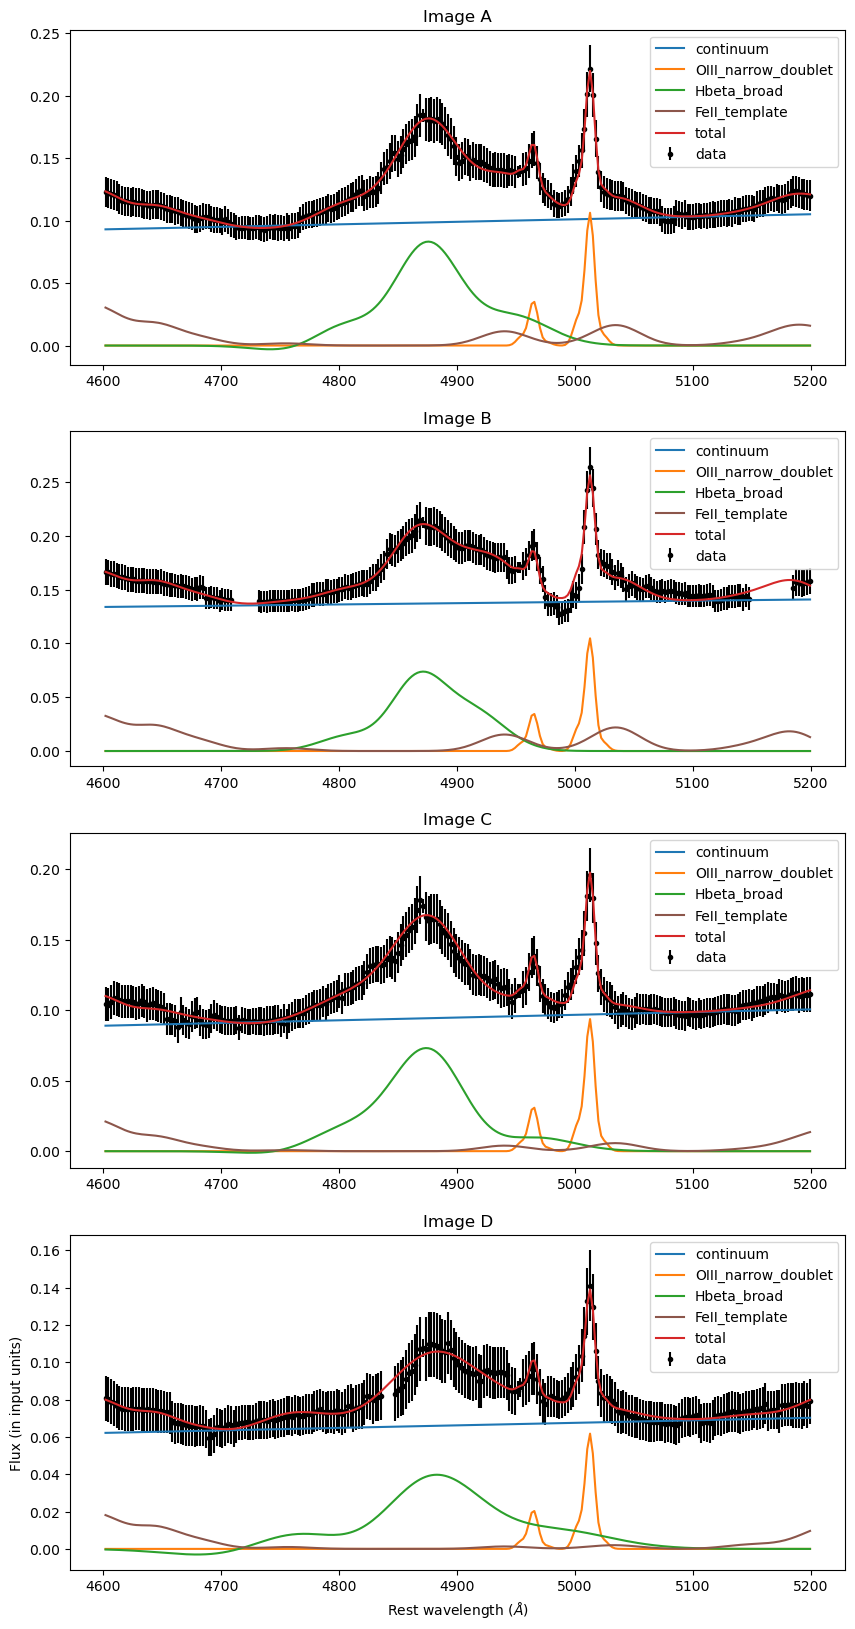

In [22]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -3e-3} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = PSO(qso_spec, n_particles=100, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.optimize(max_iter=1000, plot=True)
#simulated_flux = qso_spec.simulateSpectra(kwargs_values, plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

Best-fitting parameters:  {'A': {'continuum': {'beta': 0.23295297657936606, 'amp': 0.09364911520463025}, 'OIII_narrow_doublet': {'dlam': 4.914042578802635, 'width': 6.085345355152384, 'relcoeffsHermite': array([0.18554236, 0.10397415, 0.07370639, 0.02343881, 0.00993643]), 'amp': 0.45569309358842097}, 'Hbeta_broad': {'dlam': -0.030105245874305357, 'width': 39.28860278764727, 'coeffsHermite': array([8.40967257, 3.05315207, 1.59365704, 0.73555163, 0.17024695,
       0.06832429])}, 'FeII_template': {'dlam': -0.12414876828206695, 'velocity': 3499.79519715135, 'F': 0.2678954183545164, 'G': 0.2875042701264994, 'IZw1': 0.2715869362965091, 'S': 0.3719245520428173}}, 'B': {'continuum': {'beta': 0.837767912764489, 'amp': 0.13789075314424426}, 'OIII_narrow_doublet': {'dlam': 4.914042578802635, 'width': 6.085345355152384, 'relcoeffsHermite': array([0.18554236, 0.10397415, 0.07370639, 0.02343881, 0.00993643]), 'amp': 0.5265435567471084}, 'Hbeta_broad': {'dlam': 1.4831903509011148, 'width': 40.263247

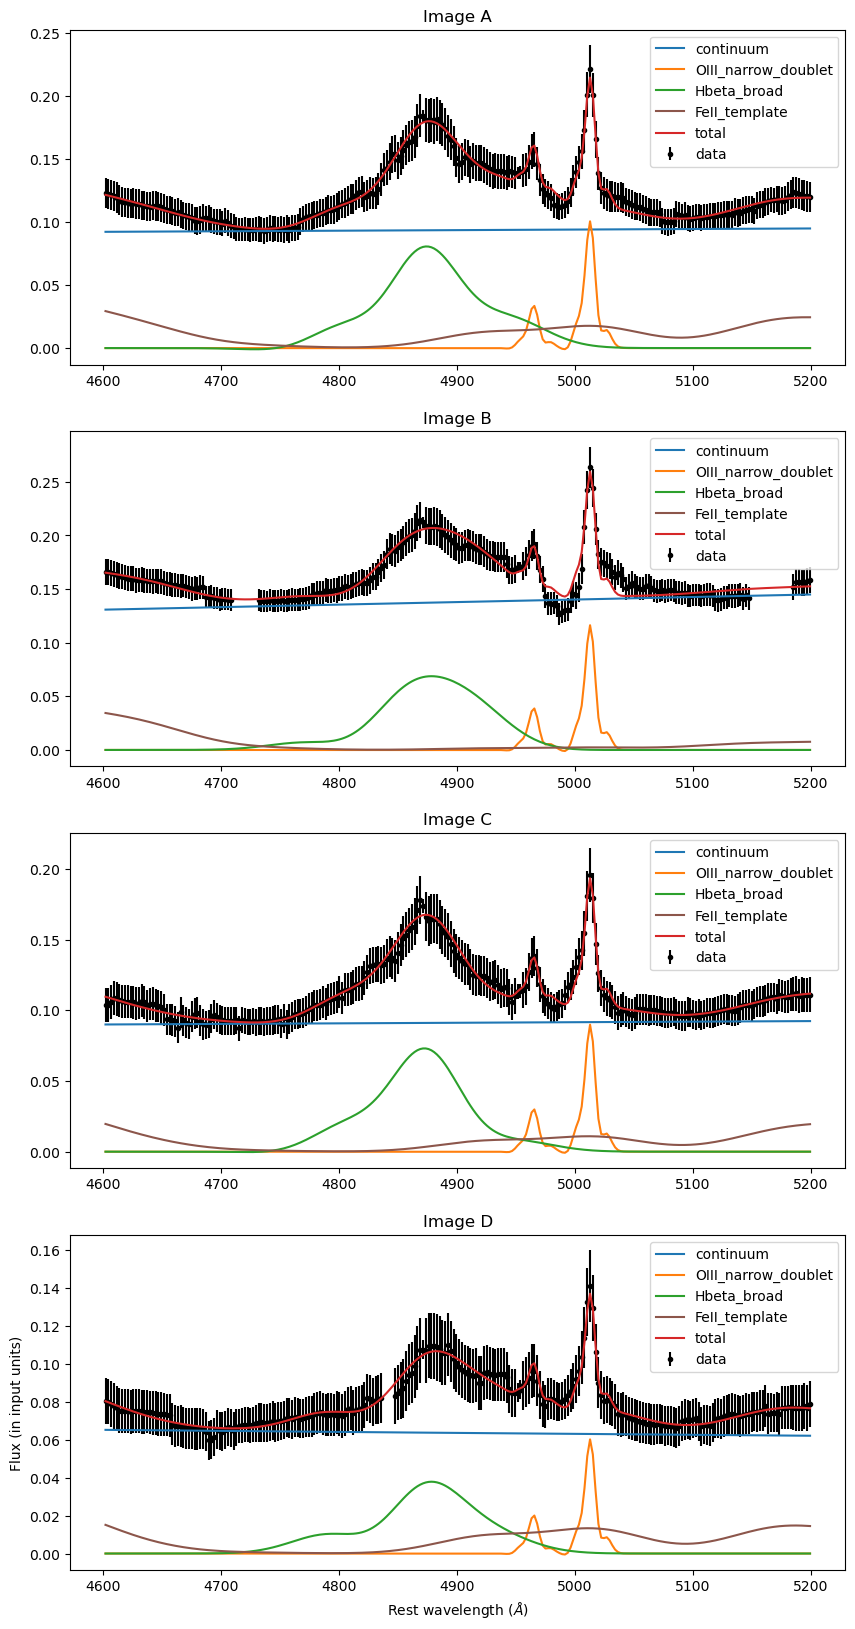

In [23]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -1e-3} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = Optimizer(qso_spec, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.find_MLE(plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

## NB: reduced chi-squared is not meaningful when there some fit parameters are not linear (cf. Andrae et al. 2010, "Dos and don'ts of reduced chi-squared")

 61%|████████████████████████████████████████████████▍                               | 606/1000 [07:09<04:39,  1.41it/s]


Converged after 606 iterations!
Best fit found:  -195.1010057597402 [2.520246521101522, 5.877039027165218, 0.41800675049479, 0.095380428716256, 0.04335284324906644, 0.0036574400620750552, 0.00760874723160234, 18.609506328099396, 33.33928234576971, -1.4166708281465197, 5986.300427340572, 19.21683085319522, 32.54829712769538, 0.26635829517834275, 37.04488878372068, 2.41140230935847, 60.781898361089304]
Best-fitting parameters:  {'A': {'continuum': {'coeffs': array([-0.03935614,  0.06655013])}, 'OIII_narrow_doublet': {'dlam': 2.520246521101522, 'width': 5.877039027165218, 'relcoeffsHermite': array([0.41800675, 0.09538043, 0.04335284, 0.00365744, 0.00760875]), 'amp': 0.4272257420913995}, 'Hbeta_broad': {'dlam': 18.609506328099396, 'width': 33.33928234576971, 'coeffsHermite': array([ 7.4708372 , -2.58145229,  1.64880306, -0.91903924,  0.17681113,
       -0.08404369])}, 'FeII_template': {'dlam': -1.4166708281465197, 'velocity': 5986.300427340572, 'F': 0.17140386786341244, 'G': 1.323360735506

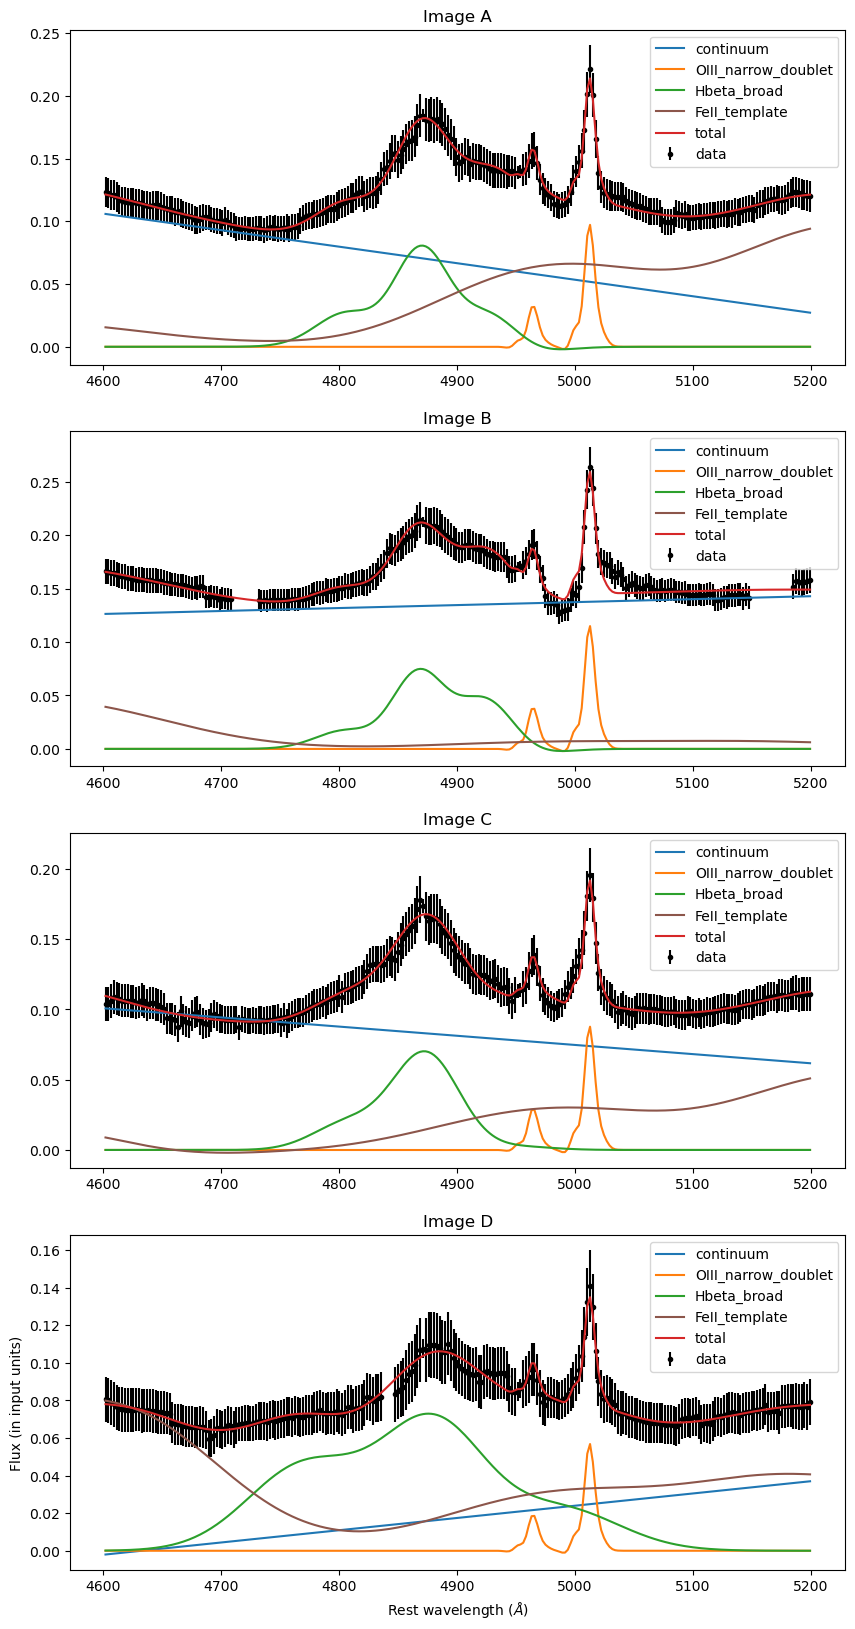

In [15]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -2e-3} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = PSO(qso_spec, n_particles=100, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.optimize(max_iter=1000, plot=True)
#simulated_flux = qso_spec.simulateSpectra(kwargs_values, plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

Best-fitting parameters:  {'A': {'continuum': {'coeffs': array([0.00246127, 0.09322623])}, 'OIII_narrow_doublet': {'dlam': 5.2419780515992995, 'width': 6.441636402068948, 'relcoeffsHermite': array([0.07867841, 0.10796253, 0.04676989, 0.02654569, 0.00713044]), 'amp': 0.4756295733952437}, 'Hbeta_broad': {'dlam': 2.2796638151182256, 'width': 39.79344540333547, 'coeffsHermite': array([8.67416688, 2.62179422, 1.63736281, 0.59612466, 0.18317507,
       0.0542533 ])}, 'FeII_template': {'dlam': -0.3829028208706096, 'velocity': 3498.8378521175414, 'F': 0.2713397952107026, 'G': 0.28486285990270654, 'IZw1': 0.31453412020557947, 'S': 0.34771137995564744}}, 'B': {'continuum': {'coeffs': array([0.00797964, 0.13901573])}, 'OIII_narrow_doublet': {'dlam': 5.2419780515992995, 'width': 6.441636402068948, 'relcoeffsHermite': array([0.07867841, 0.10796253, 0.04676989, 0.02654569, 0.00713044]), 'amp': 0.5404412550479616}, 'Hbeta_broad': {'dlam': 0.6361757181551114, 'width': 38.680791305386485, 'coeffsHermit

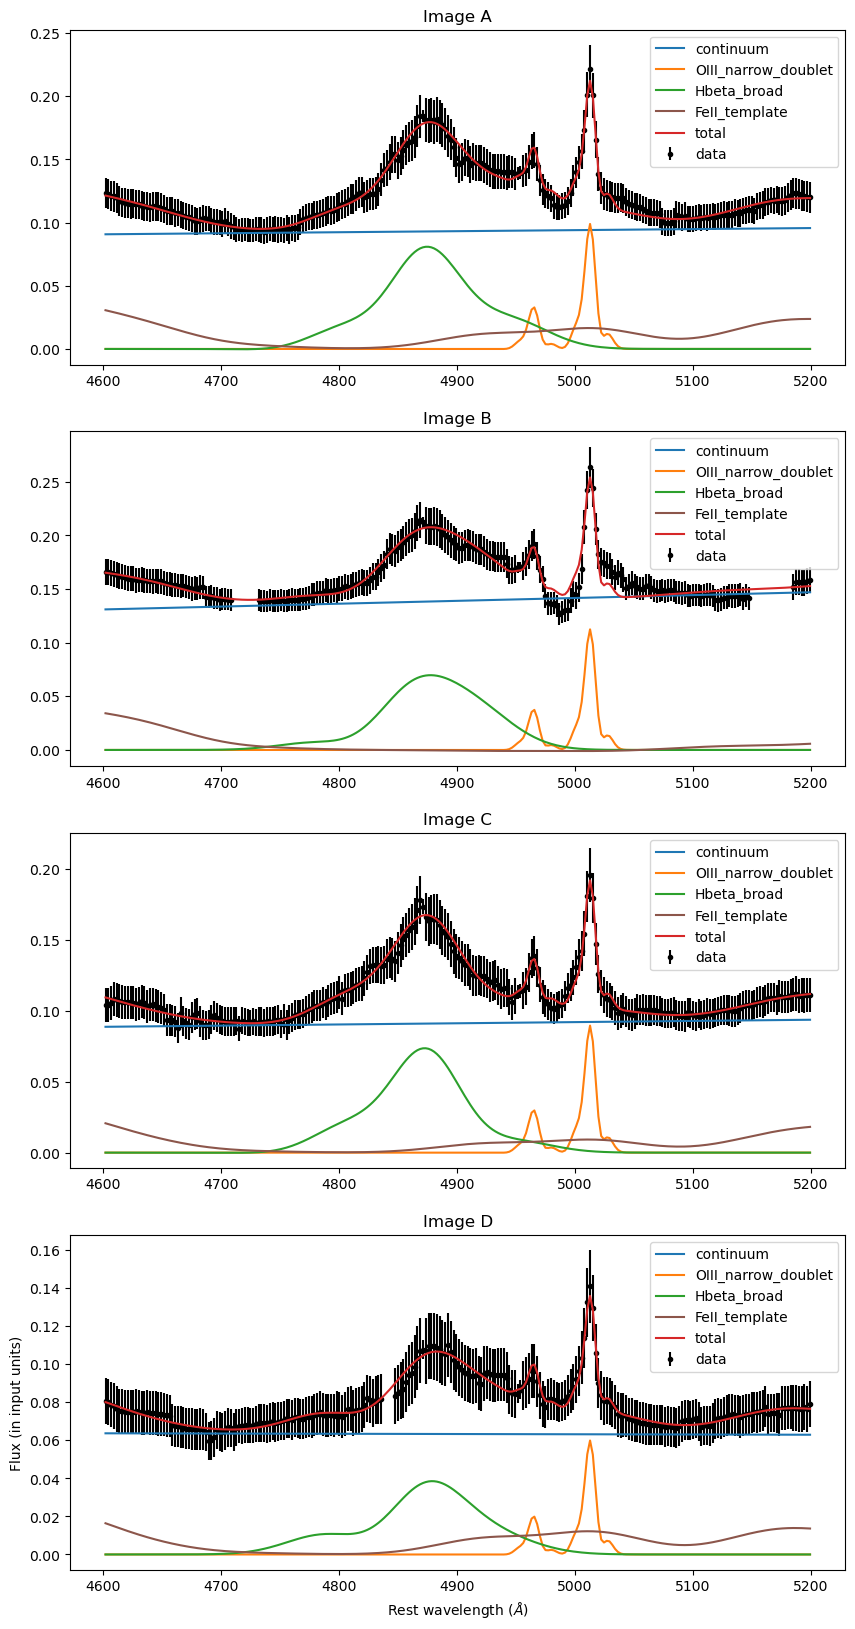

In [9]:
kwargs_likelihood = {'mask_dict':{'B': mask_B, 'D': mask_D},
                     'tol_positive': -1e-3} #consider a flux as positive above this value (likelihood will be -np.inf if one spectral component has negative flux somewhere)

opt = Optimizer(qso_spec, kwargs_likelihood=kwargs_likelihood)
logL, kwargs_values = opt.find_MLE(plot=True)

print('Best-fitting parameters: ', kwargs_values)
print('Log-likelihood: ', logL)
print('Number of free (non-linear) parameters: ', len(qso_spec.param_handler.free_nonlinear_param_list))
print('Number of free (linear + non-linear) parameters: ', qso_spec.param_handler.nb_free_params)

## NB: reduced chi-squared is not meaningful when there some fit parameters are not linear (cf. Andrae et al. 2010, "Dos and don'ts of reduced chi-squared")

## Testing

0.11791396609360962
['continuum_amp', 'OIII_narrow_doublet_amp', 'Hbeta_broad_coeffsHermite0', 'Hbeta_broad_coeffsHermite1', 'Hbeta_broad_coeffsHermite2', 'Hbeta_broad_coeffsHermite3', 'Hbeta_broad_coeffsHermite4', 'Hbeta_broad_coeffsHermite5', 'FeII_template_F', 'FeII_template_G', 'FeII_template_IZw1', 'FeII_template_S']
(-42.25959596631115, {'continuum': {'beta': 0, 'amp': 0.0913901852778166}, 'OIII_narrow_doublet': {'width': 6.3, 'dlam': 5, 'relcoeffsHermite': array([0.01, 0.01, 0.  ]), 'amp': 0.44531115310515645}, 'Hbeta_broad': {'width': 30, 'dlam': 10, 'coeffsHermite': array([8.14804286, 0.7573158 , 2.51516408, 0.18024544, 0.2807591 ,
       0.01020968])}, 'FeII_template': {'dlam': 10, 'velocity': 3700, 'F': 0.2613103845303517, 'G': 0.3125383411683012, 'IZw1': 0.23534310166640568, 'S': 0.5234774518785341}})


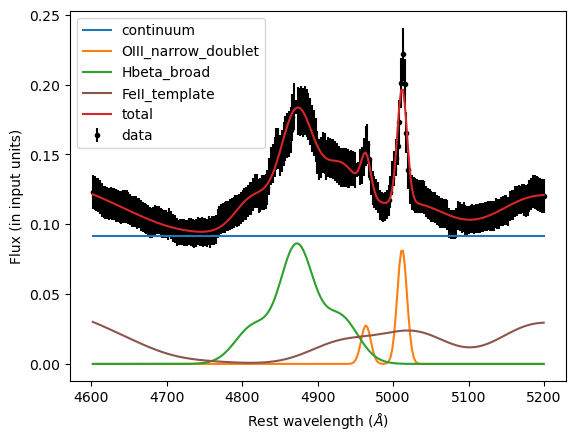

In [20]:
data = np.load('example_spectrum_A.npy')
data[2][data[2]<5e-3] = 5e-3 #some points have understimated error
print(np.average(data[1], weights=1/data[2]**2))
qso_1spec = QuasarSpectrum(data, kwargs_model, narrow_doublet_linHerm=[])

kwargs_nonlinear = {'continuum': {'beta':0},
                    'OIII_narrow_doublet': {'width':6.3, 'dlam':5, 
                                            'relcoeffsHermite': np.array([0.01, 0.01, 0.])
                                            },
                    'Hbeta_broad':{'width':30, 'dlam':10},
                    #'Hbeta_narrow':{'width':5, 'dlam':10},
                    'FeII_template':{'dlam':10, 'velocity':3700}
                   }

fig, ax = plt.subplots()
#print(qso_1spec.make_transposed_response_matrix(kwargs_nonlinear))
print(qso_1spec.lin_param_handler.linear_param_list)
print(qso_1spec.log_likelihood(kwargs_nonlinear, plot_ax=ax))